<a href="https://colab.research.google.com/github/chinh-hoangduc/QuantEcon-exercises/blob/main/sandbox_misallocation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!pip install jax

In [38]:
from typing import NamedTuple
import numpy as np
from scipy.stats import multivariate_normal, norm
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.scipy as jsp
import jax
import quantecon as qe
from functools import partial

First, we define the class for households.

This one includes age, asset grid, initial endowment (`θ_grid`, `P_grid`), and the weights/probability of being in each pair of endowment.

In [39]:
class Household(NamedTuple):
    T: int
    β: float
    a_grid: jnp.ndarray
    θ_grid: jnp.ndarray
    P_grid: jnp.ndarray
    endow_wts: jnp.ndarray

def create_household(
    T: int = 22, β: float = 0.92,
    a_min: float = 0, a_num: int = 150,
    θ_num: int = 9, P_num: int = 25,
    σ_θ: float = 0.4, σ_P: float = 0.5, ρ: float = 0.4,
    n_std: int = 4,
) -> Household:

    a_max = jnp.exp(n_std * σ_P) + 1   # align wealth grid of generations
    a_grid = jnp.linspace(a_min, a_max, a_num)


    def create_endowment_grid(θ_num, P_num, σ_θ, σ_P, ρ, n_std):
        # 1. Marginal nodes: equally spaced in log space (over ±n_std * sigma)
        log_θ = jnp.linspace(-n_std * σ_θ, n_std * σ_θ, θ_num)
        log_P = jnp.linspace(-n_std * σ_P, n_std * σ_P, P_num)

        # 2. Cell boundaries: midpoints, extended to ±inf at the tails
        def edges(x):
            mids = jnp.asarray(0.5 * (x[:-1] + x[1:]))
            return jnp.concatenate([jnp.array([-jnp.inf]), mids, jnp.array([jnp.inf])])
        e_θ = edges(log_θ)   # length n_theta + 1
        e_P = edges(log_P)   # length n_P + 1

        # 3. Cell probabilities from the bivariate normal CDF
        Sigma = np.array([[σ_θ**2, ρ * σ_θ * σ_P],
                          [ρ * σ_θ * σ_P, σ_P**2]])
        rv = multivariate_normal(mean=[0.0, 0.0], cov=Sigma)

        # CDF at each corner, then inclusion–exclusion for the rectangle mass
        T, P = np.meshgrid(e_θ, e_P, indexing='ij')          # (n_theta+1, n_P+1)
        C = rv.cdf(np.stack([T.ravel(), P.ravel()], axis=-1)).reshape(T.shape)
        W = C[1:,1:] - C[:-1,1:] - C[1:,:-1] + C[:-1,:-1]        # (n_theta, n_P)
        W = W / W.sum()

        # 4. Return levels (not logs) plus the joint weight matrix
        θ_grid = jnp.asarray(np.exp(log_θ))
        P_grid = jnp.asarray(np.exp(log_P))
        endow_wts = jnp.asarray(W)
        return θ_grid, P_grid, endow_wts

    θ_grid, P_grid, endow_wts = create_endowment_grid(θ_num, P_num, σ_θ, σ_P, ρ, n_std)


    return Household(T, β, a_grid, θ_grid, P_grid, endow_wts)

In [40]:
household = create_household()

Then, we define the class for occupation-specific shocks on human capital accumulation.

People in different occupations will receive different shock processes.

In this simple model version, that coincides with two educational level since there are only two occupations.

In [41]:
class Shock(NamedTuple):
    ε_grid: jnp.ndarray
    Π: jnp.ndarray
    μ_ε: jnp.ndarray

def create_shock(ρ: float, σ_η: float, n: int = 7) -> Shock:
    mc = qe.markov.approximation.rouwenhorst(n, ρ, σ_η)
    Π = jnp.asarray(mc.P)
    ε_grid = jnp.asarray(mc.state_values)

    # Stationary distribution: left eigenvector of Pi with eigenvalue 1
    μ_ε = jnp.asarray(mc.stationary_distributions[0])
    return Shock(ε_grid, Π, μ_ε)

In [42]:
shock_1 = create_shock(ρ=0.8836, σ_η=0.2744, n=7)   # Both education level can do job 1
shock_2 = create_shock(ρ=0.9216, σ_η=0.2356, n=7)   # Only college graduate can do job 2

/tmp/ipykernel_292/3854515630.py:7: UserWarning: The API of rouwenhorst has changed from `rouwenhorst(n, ybar, sigma, rho)` to `rouwenhorst(n, rho, sigma, mu=0.)`. To find more details please visit: https://github.com/QuantEcon/QuantEcon.py/issues/663.
  mc = qe.markov.approximation.rouwenhorst(n, ρ, σ_η)


We then define firms.

In [43]:
class Firm(NamedTuple):
    α: float
    A1: float
    A2: float
    σ: float
    δ: float

def create_firm(
    α: float = 0.36,
    A1: float = 1,
    A2: float = 1.5,
    σ: float = 2,
    δ: float = 0.11,
) -> Firm:
    return Firm(α, A1, A2, σ, δ)

In [44]:
firm = create_firm()

Then we define some functions for preferences and the factor prices.

In [45]:
γ = 1.5

def bequest(a, abar = 2.0, ψ = 1.2):
    return ψ * (a + abar)**(1 - γ) / (1 - γ)

def u(c):
    return c**(1 - γ) / (1 - γ)

def u_p(c):
    return c**(-γ)

def u_p_inv(x):
    return x**(1/(-γ))

In [46]:
def interest(L1, L2, K, firm: Firm):
    α, A1, A2, σ, δ = firm
    Lbar = (A1 * L1 ** ((σ - 1)/σ) + A2 * L2 ** ((σ - 1)/σ)) ** (σ/(σ - 1))
    return α * (Lbar / K) ** (1 - α) - δ

def wages(L1, L2, K, firm: Firm):
    α, A1, A2, σ, δ = firm
    Lbar = (A1 * L1 ** ((σ - 1)/σ) + A2 * L2 ** ((σ - 1)/σ)) ** (σ/(σ - 1))
    Y = K**α * Lbar**(1-α)
    w1 = (1 - α) * Y/Lbar * A1 * (Lbar/L1)**(1/σ)
    w2 = (1 - α) * Y/Lbar * A2 * (Lbar/L2)**(1/σ)
    return w1, w2

Functional form for initial transfers.

In [47]:
def transfer(P, τ0 = 1., τ1 = 0.5, ϕ0 = 0.7, ϕ1 = 1.):
    τN = τ0 * P ** ϕ0
    τC = τN + τ1 * P ** ϕ1
    return τN, τC

Functional form for skill upgrade.

In [48]:
def upskill(θ, P, ζ1 = 0.15, ζ2 = 0.05, ζ3 = 0.03):
    log_θ = jnp.log(θ)
    log_P = jnp.log(P)
    return jnp.exp(log_θ + ζ1 + ζ2 * log_P + ζ3 * log_θ * log_P)

Exogenous probability of dropout.

In [49]:
def dropout(θ, P, δ1 = 0.6, δ2 = 0.8, δ3 = 0.5, δ4 = 0.2):
    log_θ = jnp.log(θ)
    log_P = jnp.log(P)
    return 1 / (1 + jnp.exp(δ1 + δ2 * log_θ + δ3 * log_P + δ4 * log_θ * log_P))

Human capital accumulation.

In [50]:
def hc_acc(θp, d, t, t0, ε, g0 = 0.04, g1 = 0.005, g2 = -0.002, g3 = 0.0002):
    return jnp.exp(jnp.log(θp) + (g0 + g1*d)*(t-t0) + (g2 + g3*d)*(t-t0)**2 + ε)

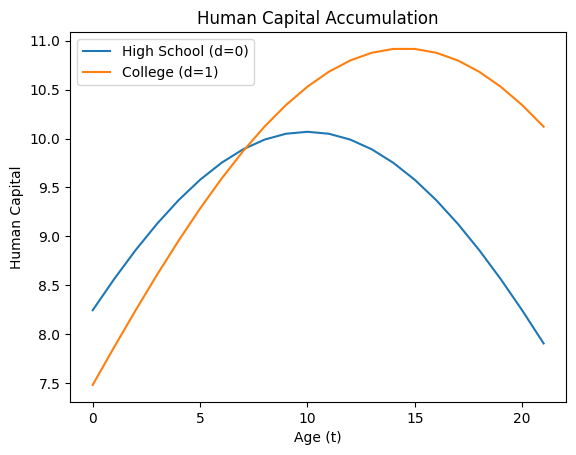

In [51]:
# @title
t_grid = np.asarray(range(22))

plt.plot(t_grid, hc_acc(5, 0, t_grid, 0, 0.5), label='High School (d=0)')
plt.plot(t_grid, hc_acc(5, 1, t_grid, 2, 0.5), label='College (d=1)')

plt.title('Human Capital Accumulation')
plt.xlabel('Age (t)')
plt.ylabel('Human Capital')
plt.legend()
plt.show()

Now we solve for the working life problem by backward induction.

The non-college type is the easiest, we will start from there.

We will solve it by VFI, keep it simple.

We will start with an initial price instance.

In [52]:
class Prices(NamedTuple):
    r: float = 0.04
    w1: float = 1.0
    w2: float = 1.2

prices = Prices()

In [62]:
def solve_HS(θ, household, prices, shock,
             d=0, t0 = 0,):

    T, β, a_grid, θ_grid, P_grid, endow_wts = household
    r, w1, w2 = prices
    ε_grid, Π, μ_ε = shock

    # placeholders for value functions and policy functions for each age
    V_all = jnp.zeros((T, a_grid.size, ε_grid.size))
    σ_idx_all = jnp.zeros((T, a_grid.size, ε_grid.size))

    # Terminal period: T = T - 1
    H_T = hc_acc(θp=θ, d=d, t=T-1, t0=t0, ε=ε_grid)   # (eps, )
    c_T = (1 + r) * a_grid[:, None, None] + w1 * H_T[None, :, None] - a_grid[None, None, :]   # (a, eps, a')
    util = jnp.where(c_T > 0, u(c_T), -jnp.inf)
    vals = util + β * bequest(a_grid)[None, None, :]   # (a, eps, a')

    V_all = V_all.at[T-1].set(jnp.max(vals, axis=-1))
    σ_idx_all = σ_idx_all.at[T-1].set(jnp.argmax(vals, axis=-1))

    # Backward induction for t < T
    for t in range(T - 2, t0 - 1, -1):
        H_t = hc_acc(θp=θ, d=d, t=t, t0=t0, ε=ε_grid)[None, :, None]
        EV  = V_all[t+1] @ Π.T
        c_t   = (1 + r)*a_grid[:, None, None] + w1*H_t - a_grid[None, None, :]
        util  = jnp.where(c_t > 0, u(c_t), -jnp.inf)
        vals = util + β * EV.T[None, :, :]   # (a, eps, a')

        V_all = V_all.at[t].set(jnp.max(vals, axis=-1))
        σ_idx_all = σ_idx_all.at[t].set(jnp.argmax(vals, axis=-1))

    return V_all, σ_idx_all

In [63]:
T, β, a_grid, θ_grid, P_grid, endow_wts = household
ε_grid, Π, μ_ε = shock_1

V_big = jnp.zeros((θ_grid.size, T, a_grid.size, ε_grid.size))
σ_idx_big = jnp.zeros((θ_grid.size, T, a_grid.size, ε_grid.size))

for θ, i in household.θ_grid:
    V_all, σ_idx_all = solve_HS(θ, household, prices, shock_1)
    V_big = V_big.at[i].set(V_all)
    σ_idx_big = σ_idx_big.at[i].set(σ_idx_all)